In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [6]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

model_data_path = (
    project_root
    / "data"
    / "processed"
    / "methane_forecasting_features_2024.parquet"
)

model_df = pd.read_parquet(model_data_path)

model_df = (
    model_df
    .sort_values(["week", "cell_id"])
    .reset_index(drop=True)
)

In [9]:
unique_weeks = np.sort(
    model_df["week"].unique()
)

test_fraction = 0.20

split_index = int(
    len(unique_weeks) * (1 - test_fraction)
)

train_weeks = unique_weeks[:split_index]
test_weeks = unique_weeks[split_index:]

train_df = model_df[
    model_df["week"].isin(train_weeks)
].copy()

test_df = model_df[
    model_df["week"].isin(test_weeks)
].copy()

In [10]:
print("Training period:")
print(train_df["week"].min(), "→", train_df["week"].max())

print("\nTest period:")
print(test_df["week"].min(), "→", test_df["week"].max())

print("\nTraining rows:", len(train_df))
print("Test rows:", len(test_df))
print("Test weeks:", len(test_weeks))

Training period:
2024-01-14 00:00:00 → 2024-10-20 00:00:00

Test period:
2024-10-27 00:00:00 → 2024-12-22 00:00:00

Training rows: 23689
Test rows: 3609
Test weeks: 9


In [12]:
y_test = test_df["target_next_week"]

persistence_predictions = test_df["CH4"]

In [13]:
persistence_errors = (
    y_test - persistence_predictions
)

persistence_mean_error = persistence_errors.mean()

persistence_mae = mean_absolute_error(
    y_test,
    persistence_predictions,
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_predictions,
    )
)

persistence_r2 = r2_score(
    y_test,
    persistence_predictions,
)

print(
    f"Mean error: {persistence_mean_error:.3f} ppb"
)
print(
    f"Persistence MAE: {persistence_mae:.3f} ppb"
)
print(
    f"Persistence RMSE: {persistence_rmse:.3f} ppb"
)
print(
    f"Persistence R²: {persistence_r2:.3f}"
)

Mean error: 0.519 ppb
Persistence MAE: 14.422 ppb
Persistence RMSE: 17.889 ppb
Persistence R²: -0.349


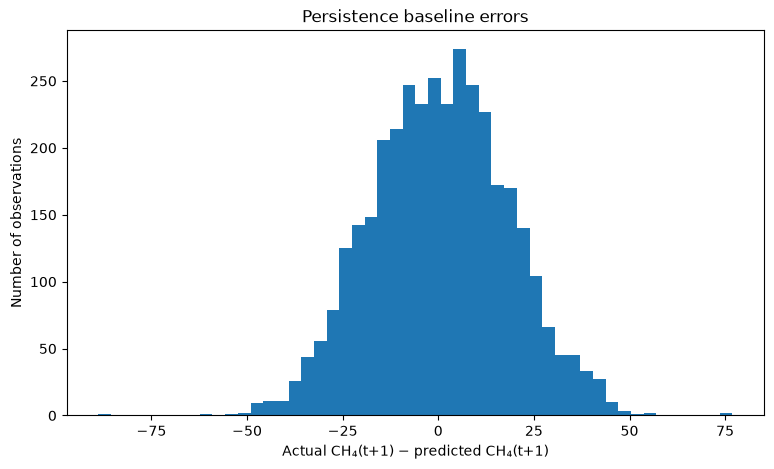

In [14]:
persistence_errors.plot.hist(
    bins=50,
    figsize=(9, 5),
)

plt.title("Persistence baseline errors")
plt.xlabel("Actual CH₄(t+1) − predicted CH₄(t+1)")
plt.ylabel("Number of observations")
plt.show()

In [15]:
weekly_baseline_errors = (
    test_df
    .assign(
        persistence_error=persistence_errors
    )
    .groupby("week", as_index=False)
    .agg(
        mean_error=("persistence_error", "mean"),
        mae=(
            "persistence_error",
            lambda values: values.abs().mean(),
        ),
    )
)

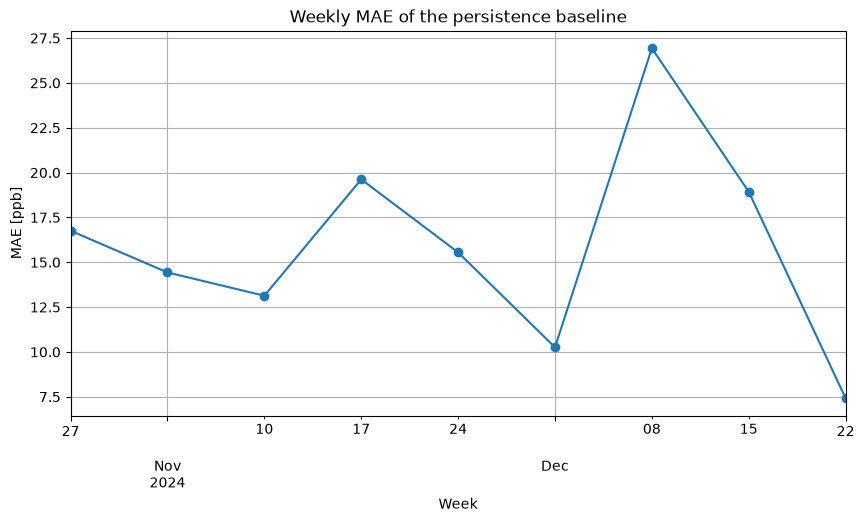

In [16]:
weekly_baseline_errors.plot(
    x="week",
    y="mae",
    figsize=(10, 5),
    marker="o",
    legend=False,
)

plt.title("Weekly MAE of the persistence baseline")
plt.xlabel("Week")
plt.ylabel("MAE [ppb]")
plt.grid()
plt.show()